<a href="https://colab.research.google.com/github/adityapawar7197-ops/PDS-PRACTICAL/blob/main/adi8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME : ADITYA PAWAR


Branch : AI&DS

Roll NO. : SYB 25

Exp No.8

AIM : Implement and analyze various methods of studying correlation and regression  including Karl Pearson’s coefficient and simple linear regression.

Theory :

1 .	What is correlation? How is it different from regression?

ANS.

Correlation is a statistical measure that describes the strength and direction of a linear relationship between two variables. It is represented by the correlation coefficient (r), which ranges from -1 to +1. A value of +1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no linear relationship. Correlation simply shows how two variables move together but does not explain cause and effect. Regression, on the other hand, is used to predict the value of one variable based on another. In regression, one variable is considered independent (X) and the other dependent (Y), and the relationship is expressed using an equation like Y = mX + c. While correlation is symmetric and treats both variables equally, regression is asymmetric because it assumes a directional influence from X to Y. Correlation provides a single value (r), whereas regression produces a prediction equation. Importantly, correlation does not imply causation, but regression is used for forecasting and prediction.







2 .	What is simple linear regression? Explain with suitable example.

ANS.

Simple Linear Regression is a statistical technique used to model the relationship between one independent variable (X) and one dependent variable (Y) by fitting a straight line to the data. The equation of the model is Y = β₀ + β₁X + ε, where Y is the dependent variable, X is the independent variable, β₀ is the intercept, β₁ is the slope, and ε represents the error term. The slope β₁ shows how much Y changes for each unit change in X, while the intercept β₀ gives the value of Y when X is zero. For example, if we want to predict a student’s exam score based on the number of hours studied, we can use regression. Suppose the resulting equation is Y = 40 + 8X. This means the student scores 40 marks even without studying, and for every additional hour of study, the scoreincreases by 8 marks. So, if a student studies for 6 hours, the predicted score would be 88.





3 .	How do you calculate Pearson correlation in Python?

ANS.

Pearson Correlation measures the linear relationship between two continuous variables. It is calculated using the formula involving covariance divided by the product of standard deviations of the variables. In Python, it can be computed in several ways. Using NumPy, we can use np.corrcoef(x, y)[0, 1] to get the correlation coefficient. Using SciPy, we can use pearsonr(x, y), which returns both the correlation value and the p-value to test statistical significance. In Pandas, correlation can be calculated using df['X'].corr(df['Y']). For multiple variables, we can use df.corr() to generate a correlation matrix. The p-value from SciPy helps determine whether the correlation is statistically significant, where p < 0.05 indicates significance.





4.What is Multicollinearity? Does it affect Simple Regression?


ANS.

Multicollinearity refers to a situation in which two or more independent variables in a regression model are highly correlated with each other. This makes it difficult to determine the individual effect of each variable on the dependent variable. It can cause instability in regression coefficients, inflate standard errors, and make interpretation unreliable. Although the overall model may still predict well, the contribution of each predictor becomes unclear. However, multicollinearity does not affect simple linear regression because simple regression has only one independent variable, so there is no possibility of correlation between predictors. Multicollinearity is only a concern in multiple linear regression models that involve two or more independent variables. It is typically detected using correlation matrices or Variance Inflation Factor (VIF), where values greater than 5 or 10 indicate a problem.







5.A dataset shows strong correlation but poor prediction accuracy. Why?


ANS.


A dataset may show strong correlation but still give poor prediction accuracy due to several reasons. First, correlation does not imply causation, so the relationship may be influenced by a hidden or confounding variable. Second, outliers can artificially increase correlation, but the model may fail on new data. Third, Pearson correlation only captures linear relationships, so if the true relationship is non-linear, a linear model will perform poorly despite high correlation. Fourth, overfitting can occur when a model fits training data too closely but fails to generalize to unseen data. Fifth, small sample sizes can give misleadingly high correlation values that do not hold for larger datasets. Finally, spurious correlations may occur where two unrelated variables appear strongly related purely by chance, especially in time-series or seasonal data.

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

DATASET CREATION

In [ ]:
np.random.seed(42)
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_scores   = np.array([50, 53, 61, 67, 75, 78, 82, 85, 90, 95])
df = pd.DataFrame({'Hours_Studied': hours_studied, 'Exam_Score': exam_scores})
print("=== Dataset ===")
print(df)
print("\nBasic Statistics:")
print(df.describe())

=== Dataset ===
   Hours_Studied  Exam_Score
0              1          50
1              2          53
2              3          61
3              4          67
4              5          75
5              6          78
6              7          82
7              8          85
8              9          90
9             10          95

Basic Statistics:
       Hours_Studied  Exam_Score
count       10.00000   10.000000
mean         5.50000   73.600000
std          3.02765   15.392639
min          1.00000   50.000000
25%          3.25000   62.500000
50%          5.50000   76.500000
75%          7.75000   84.250000
max         10.00000   95.000000


1 . SCATTER PLOT

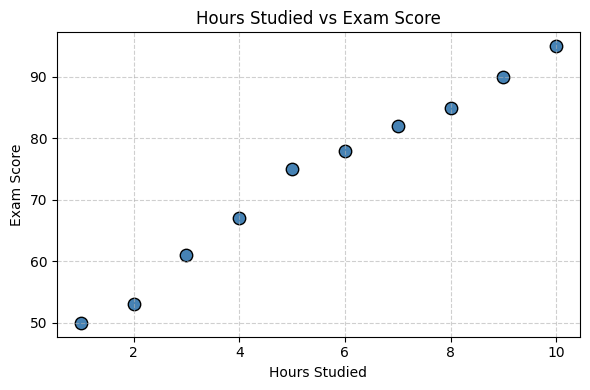

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='steelblue', s=80, edgecolors='black')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

2 . KARL PEARSON'S CORRELATION COEFFICIENT

In [ ]:
# Method 1: NumPy
r_numpy = np.corrcoef(df['Hours_Studied'], df['Exam_Score'])[0, 1]

# Method 2: SciPy
r_scipy, p_value = pearsonr(df['Hours_Studied'], df['Exam_Score'])

# Method 3: Pandas
r_pandas = df['Hours_Studied'].corr(df['Exam_Score'])

print("\n=== Karl Pearson's Correlation Coefficient ===")
# Removed the invalid URL and separated print statements
print(f"r (NumPy)  : {r_numpy:.4f}")
print(f"r (SciPy)  : {r_scipy:.4f}")
print(f"r (Pandas) : {r_pandas:.4f}")
print(f"p-value    : {p_value:.6f}")

if p_value < 0.05:
    print("Result: Correlation is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result: Correlation is NOT statistically significant")

if r_scipy > 0.8:
    print("Interpretation: STRONG POSITIVE correlation")
elif r_scipy > 0.5:
    print("Interpretation: MODERATE POSITIVE correlation")
elif r_scipy > 0:
    print("Interpretation: WEAK POSITIVE correlation")
else:
    print("Interpretation: NEGATIVE correlation")


=== Karl Pearson's Correlation Coefficient ===
r (NumPy)  : 0.9918
r (SciPy)  : 0.9918
r (Pandas) : 0.9918
p-value    : 0.000000
Result: Correlation is STATISTICALLY SIGNIFICANT (p < 0.05)
Interpretation: STRONG POSITIVE correlation


3 . CORRELATION HEATMAP

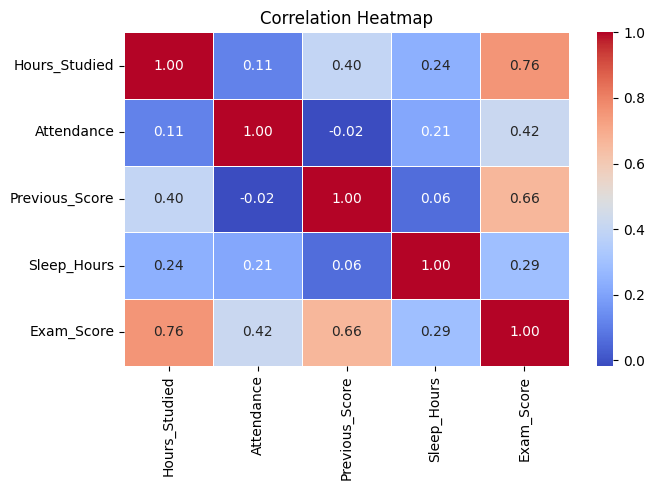


=== Correlation Matrix ===
                Hours_Studied  Attendance  Previous_Score  Sleep_Hours  \
Hours_Studied           1.000       0.112           0.397        0.239   
Attendance              0.112       1.000          -0.017        0.213   
Previous_Score          0.397      -0.017           1.000        0.059   
Sleep_Hours             0.239       0.213           0.059        1.000   
Exam_Score              0.758       0.419           0.663        0.292   

                Exam_Score  
Hours_Studied        0.758  
Attendance           0.419  
Previous_Score       0.663  
Sleep_Hours          0.292  
Exam_Score           1.000  


In [ ]:
# Extended dataset with more variables
np.random.seed(0)
data_ext = pd.DataFrame({
    'Hours_Studied': np.random.randint(1, 11, 50),
    'Attendance': np.random.randint(60, 100, 50),
    'Previous_Score': np.random.randint(40, 90, 50),
    'Sleep_Hours': np.random.randint(4, 10, 50),
})
data_ext['Exam_Score'] = (2.5 * data_ext['Hours_Studied'] +
                          0.3 * data_ext['Attendance'] +
                          0.4 * data_ext['Previous_Score'] +
                          np.random.normal(0, 5, 50))
plt.figure(figsize=(7, 5))
sns.heatmap(data_ext.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\n=== Correlation Matrix ===")
print(data_ext.corr().round(3))

4 . SIMPLE LINEAR REGRESSION (Manual Calculation)

In [ ]:
X = df['Hours_Studied'].values
Y = df['Exam_Score'].values
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Calculate slope (beta1) and intercept (beta0)
numerator   = np.sum((X - X_mean) * (Y - Y_mean))
denominator = np.sum((X - X_mean) ** 2)
beta1 = numerator / denominator
beta0 = Y_mean - beta1 * X_mean

print("\n=== Simple Linear Regression (Manual) ===")
print(f"Slope     (β₁) : {beta1:.4f}")
print(f"Intercept (β₀) : {beta0:.4f}")
print(f"Regression Equation: Y = {beta0:.2f} + {beta1:.2f} * X")

# Predict
Y_pred_manual = beta0 + beta1 * X
print("\nActual vs Predicted (Manual):")
for i in range(len(X)):
  print(f"  X={X[i]}, Actual={Y[i]}, Predicted={Y_pred_manual[i]:.2f}")


=== Simple Linear Regression (Manual) ===
Slope     (β₁) : 5.0424
Intercept (β₀) : 45.8667
Regression Equation: Y = 45.87 + 5.04 * X

Actual vs Predicted (Manual):
  X=1, Actual=50, Predicted=50.91
  X=2, Actual=53, Predicted=55.95
  X=3, Actual=61, Predicted=60.99
  X=4, Actual=67, Predicted=66.04
  X=5, Actual=75, Predicted=71.08
  X=6, Actual=78, Predicted=76.12
  X=7, Actual=82, Predicted=81.16
  X=8, Actual=85, Predicted=86.21
  X=9, Actual=90, Predicted=91.25
  X=10, Actual=95, Predicted=96.29


5 . SIMPLE LINEAR REGRESSION (Scikit-Learn)

In [ ]:
X_sk = df[['Hours_Studied']]
Y_sk = df['Exam_Score']
X_train, X_test, Y_train, Y_test = train_test_split(X_sk, Y_sk, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred_sk = model.predict(X_test)

print("\n=== Simple Linear Regression (Scikit-Learn) ===")
print(f"Slope     (β₁) : {model.coef_[0]:.4f}")
print(f"Intercept (β₀) : {model.intercept_:.4f}")
print(f"R² Score       : {r2_score(Y_test, Y_pred_sk):.4f}")
print(f"MSE            : {mean_squared_error(Y_test, Y_pred_sk):.4f}")
print(f"RMSE           : {np.sqrt(mean_squared_error(Y_test, Y_pred_sk)):.4f}")


=== Simple Linear Regression (Scikit-Learn) ===
Slope     (β₁) : 4.9397
Intercept (β₀) : 46.9569
R² Score       : 0.9756
MSE            : 8.3576
RMSE           : 2.8910


6 . REGRESSION LINE PLOT

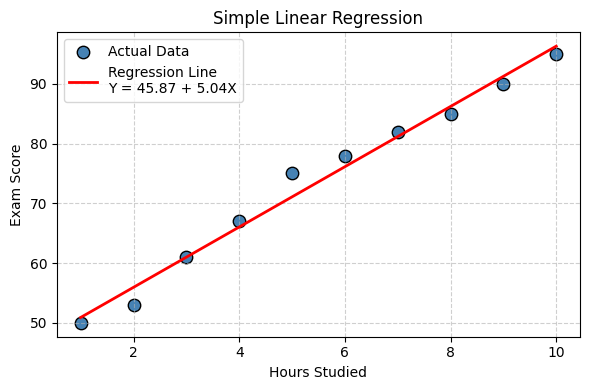

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X, Y, color='steelblue', s=80, edgecolors='black', label='Actual Data')
plt.plot(X, Y_pred_manual, color='red', linewidth=2, label=f'Regression Line\nY = {beta0:.2f} + {beta1:.2f}X')
plt.title('Simple Linear Regression')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

7 . RESIDUAL PLOT

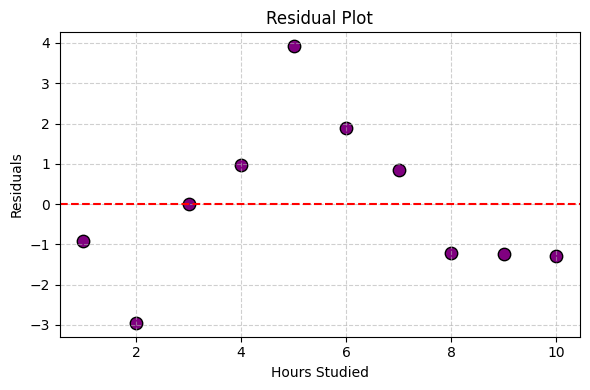


=== Residuals ===
  X=1, Residual=-0.91
  X=2, Residual=-2.95
  X=3, Residual=0.01
  X=4, Residual=0.96
  X=5, Residual=3.92
  X=6, Residual=1.88
  X=7, Residual=0.84
  X=8, Residual=-1.21
  X=9, Residual=-1.25
  X=10, Residual=-1.29
Sum of Residuals : 0.000000 (should be ~0)


In [ ]:
residuals = Y - Y_pred_manual
plt.figure(figsize=(6, 4))
plt.scatter(X, residuals, color='purple', s=80, edgecolors='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot')
plt.xlabel('Hours Studied')
plt.ylabel('Residuals')
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n=== Residuals ===")
for i in range(len(X)):
  print(f"  X={X[i]}, Residual={residuals[i]:.2f}")
print(f"Sum of Residuals : {np.sum(residuals):.6f} (should be ~0)")

CONCLUSION :

This experiment implemented and analyzed correlation and simple linear regression in Python. Karl Pearson's correlation coefficient was calculated using NumPy, SciPy, and Pandas, confirming a strong positive relationship between hours studied and exam scores. The regression equation was derived both manually using the least squares formula and using Scikit-Learn, producing consistent results. The regression line, residual plot, and correlation heatmap provided visual confirmation of the relationships. It was observed that while st